# Joins & Merges in pandas
In pandas, the primary methods for combining data are `merge()`, `join()` & `concat()`. <br>
The best method to use depends on whether you want to combine based on shared columns (keys), row indices, or simply stack the dataframes

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## The `pd.merge()` method
The pd.merge() function is the most flexible method, performing SQL-style join operations based on common columns or indices. It is used for combining dataframes where the relationship between rows is based on shared key values. Important params are:<br>
`left` - The first df on the left<br>
`right` - second df on the right<br>
`on` - the common column in both the tables<br>
`how` - type of join to be implemented ((default)inner/ left/ right/ outer/ cross) etc.

**Syntax could be -**<br>
`pd.merge(left=T1df , right= T2df, on="col_name", how= )` OR

`T1df.merge(T2df, on="col_name", how= )` 

>Working on data on various wards of the city of Chicago -- office locations , census, land use 

In [147]:
# Loading the offices & census datasets
offices = pd.read_pickle("./datasets_joins_merges/ward.p")
census= pd.read_pickle("./datasets_joins_merges/census.p")
licenses = pd.read_pickle("./datasets_joins_merges/licenses.p")
zip = pd.read_pickle("./datasets_joins_merges/zip_demo.p")
print(f"offices- {offices.shape} ; census- {census.shape} ; licenses- {licenses.shape}" )

offices- (50, 4) ; census- (50, 6) ; licenses- (10000, 6)


In [3]:
offices.head()

,ward,alderman,address,zip
0,1,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647
1,2,Brian Hopkins,1400 NORTH ASHLAND AVENUE,60622
2,3,Pat Dowell,5046 SOUTH STATE STREET,60609
3,4,William D. Burns,"435 EAST 35TH STREET, 1ST FLOOR",60616
4,5,Leslie A. Hairston,2325 EAST 71ST STREET,60649


In [4]:
census.head()

,ward,pop_2000,pop_2010,change,address,zip
0,1,52951,56149,6%,2765 WEST SAINT MARY STREET,60647
1,2,54361,55805,3%,WM WASTE MANAGEMENT 1500,60622
2,3,40385,53039,31%,17 EAST 38TH STREET,60653
3,4,51953,54589,5%,31ST ST HARBOR BUILDING LAKEFRONT TRAIL,60653
4,5,55302,51455,-7%,JACKSON PARK LAGOON SOUTH CORNELL DRIVE,60637


Merging the offices with census table using the **common** "ward" column . This will give a unified table that shows ward office locations , the alderman of that ward , along with the population census

In [5]:
offices_census = pd.merge(left=offices , right= census , how="inner" , on="ward")
offices_census.head()

,ward,alderman,address_x,zip_x,pop_2000,pop_2010,change,address_y,zip_y
0,1,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647,52951,56149,6%,2765 WEST SAINT MARY STREET,60647
1,2,Brian Hopkins,1400 NORTH ASHLAND AVENUE,60622,54361,55805,3%,WM WASTE MANAGEMENT 1500,60622
2,3,Pat Dowell,5046 SOUTH STATE STREET,60609,40385,53039,31%,17 EAST 38TH STREET,60653
3,4,William D. Burns,"435 EAST 35TH STREET, 1ST FLOOR",60616,51953,54589,5%,31ST ST HARBOR BUILDING LAKEFRONT TRAIL,60653
4,5,Leslie A. Hairston,2325 EAST 71ST STREET,60649,55302,51455,-7%,JACKSON PARK LAGOON SOUTH CORNELL DRIVE,60637


Note the repeated columns from both dataframes (address & zip) are suffixed as `_x` & `_y`. 

The `suffixes` param can be passed a tuple containing custom column names. This helps to better distinguish the column names & their origin.

In [ ]:
# Using suffixes parameter to add custom suffixes
offices_census1 = pd.merge(left=offices , right= census , how="inner" , on="ward", suffixes=('_ofc','_cns'))
offices_census1.head(3)

,ward,alderman,address_ofc,zip_ofc,pop_2000,pop_2010,change,address_cns,zip_cns
0,1,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647,52951,56149,6%,2765 WEST SAINT MARY STREET,60647
1,2,Brian Hopkins,1400 NORTH ASHLAND AVENUE,60622,54361,55805,3%,WM WASTE MANAGEMENT 1500,60622
2,3,Pat Dowell,5046 SOUTH STATE STREET,60609,40385,53039,31%,17 EAST 38TH STREET,60653


## Understanding relationships in df
**One-to-one** - every row in df1 is related to only one row in df2. Example: the above `offices_census` join 

**One-to-many** - every row in df1 is related to more than 1 row in df2. Example: the `offices_licenses` join below -- every ward has multiple businesses.<br>So the df1 (offices) rows are repeated for several of the df2 (licenses) rows.

In [11]:
offices_licenses = offices.merge(licenses , on="ward", suffixes=('_ofc', '_lcn'))
offices_licenses.head()

,ward,alderman,address_ofc,zip_ofc,account,aid,business,address_lcn,zip_lcn
0,1,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647,12024,NaN,DIGILOG ELECTRONICS,1038 N ASHLAND AVE,60622
1,1,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647,14446,743,EMPTY BOTTLE INC,1035 N WESTERN AVE 1ST,60622
2,1,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647,14624,775,LITTLE MEL'S HOT DOG,2205 N CALIFORNIA AVE,60647
3,1,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647,14987,NaN,MR. BROWN'S LOUNGE,2301 W CHICAGO AVE 1ST,60622
4,1,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647,15642,814,Beat Kitchen,2000-2100 W DIVISION ST,60622


## Merging Multiple tables - 1
The `licenses` & `wards` table to be merged with `zip_demo` table to gain insights on ward-wise median income.

Find median income by alderman.

In [151]:
licenses_ward_zip = licenses.merge(zip , on="zip").merge(offices, on="ward")
licenses_ward_zip.head()

,account,ward,aid,business,address_x,zip_x,income,alderman,address_y,zip_y
0,307071,3,743,REGGIE'S BAR & GRILL,2105 S STATE ST,60616,46340,Pat Dowell,5046 SOUTH STATE STREET,60609
1,10,10,829,HONEYBEERS,13200 S HOUSTON AVE,60633,50164,Susan Sadlowski Garza,10500 SOUTH EWING AVENUE,60617
2,10002,14,775,CELINA DELI,5089 S ARCHER AVE,60632,42335,Edward M. Burke,2650 WEST 51ST STREET,60632
3,10005,12,NaN,KRAFT FOODS NORTH AMERICA,2005 W 43RD ST,60609,33959,George Cardenas,3476 SOUTH ARCHER AVENUE,60608
4,10044,44,638,NEYBOUR'S TAVERN & GRILLE,3651 N SOUTHPORT AVE,60613,79565,Tom Tunney,3223 NORTH SHEFFIELD AVENUE,60657


In [157]:
cta_stats1 = licenses_ward_zip.groupby("alderman").agg(median_income=("income","median") , no_of_biz=("business","count")).round(2)
cta_stats1.head()

,median_income,no_of_biz
alderman,,
Ameya Pawar,66246.0,275
Anthony A. Beale,38206.0,101
Anthony V. Napolitano,82226.0,153
Ariel E. Reyboras,41307.0,186
Brendan Reilly,110215.0,1369


Finding median income per ward

In [164]:
cta_stats2 = licenses_ward_zip.groupby("ward").agg(median_income=("income","median") , no_of_biz=("business","count")).round(2).reset_index()
cta_stats2.head()

,ward,median_income,no_of_biz
0,1,87143.0,253
1,10,38417.0,130
2,11,41226.0,201
3,12,33959.0,255
4,13,67045.0,101


In [174]:
offices_licenses.dtypes

ward           object
alderman       object
address_ofc    object
zip_ofc        object
account        object
aid            object
business       object
address_lcn    object
zip_lcn        object
dtype: object

Visualizing of businesses for each ward

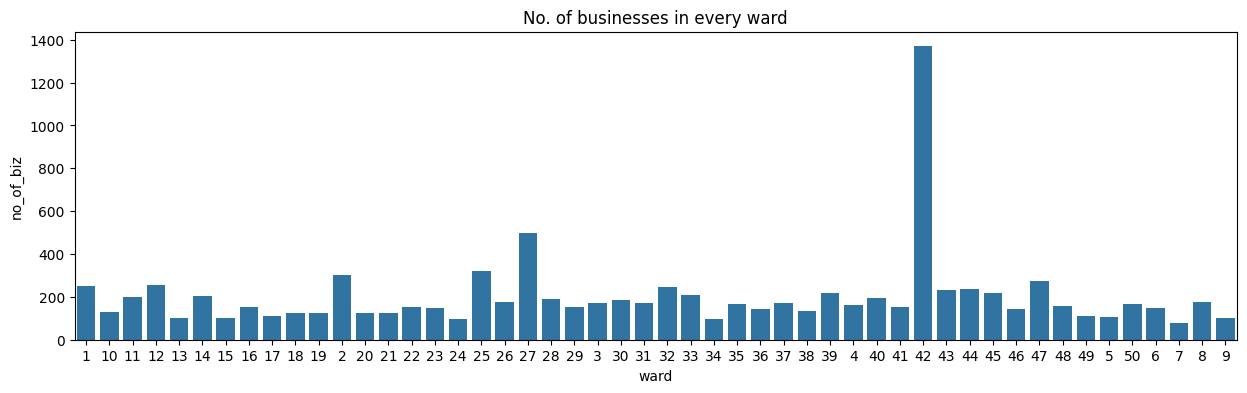

In [170]:
plt.figure(figsize=(15,4))
sns.barplot(data=cta_stats2, x="ward", y="no_of_biz")
plt.title("No. of businesses in every ward")
plt.show()


>- Its observed that ward no. 42 has most amount of businesses. Ward# 27 comes a distant second followed closely by ward# 25.

In [176]:
offices_licenses[offices_licenses["ward"]=="42"].shape

(1371, 9)

## Merging Multiple tables - 2

Find the ridership trends of Chicago public transport system for 2019. Data is available across 3 differnt tables - `cal` `ridership` `stations`

In [32]:
cal = pd.read_pickle("./datasets_joins_merges/cta_calendar.p")
ridership = pd.read_pickle("./datasets_joins_merges/cta_ridership.p")
stations = pd.read_pickle("./datasets_joins_merges/stations.p")

In [39]:
# merging all 3 tables in one line
rdshp_cal_stn = ridership.merge(cal, on=["year", "month", "day"]).merge(stations, on="station_id")
rdshp_cal_stn.head()

,station_id,year,month,day,rides,day_type,station_name,location
0,40010,2019,1,1,576,Sunday/Holiday,Austin-Forest Park,"(41.870851, -87.776812)"
1,40010,2019,1,2,1457,Weekday,Austin-Forest Park,"(41.870851, -87.776812)"
2,40010,2019,1,3,1543,Weekday,Austin-Forest Park,"(41.870851, -87.776812)"
3,40010,2019,1,4,1621,Weekday,Austin-Forest Park,"(41.870851, -87.776812)"
4,40010,2019,1,5,719,Saturday,Austin-Forest Park,"(41.870851, -87.776812)"


The `stations` df has 144 stations with unique IDs, while `cal` is a calender table for 2019. The `ridership` df contains total daily rides for 9 of the 144 stations.

In [90]:
# stations["station_id"].nunique()
# rdshp_cal_stn.shape
# cal["year"].value_counts()
ridership["station_id"].nunique()

9

In [76]:
# Find total monthly rides per station (Grouping & aggregation)
cta_gb1 = rdshp_cal_stn.groupby(["station_name","month"])[["rides"]].agg(rides_avg=("rides","mean"),rides_total=("rides","sum")).reset_index()
cta_gb1.head()

,station_name,month,rides_avg,rides_total
0,35th/Archer,1,2041.290323,63280
1,35th/Archer,2,2351.107143,65831
2,35th/Archer,3,2404.838710,74550
3,35th/Archer,4,2497.833333,74935
4,35th/Archer,5,2567.258065,79585


C:\Users\abhijeet.bhambere\AppData\Local\Temp\ipykernel_29316\2137203444.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(),rotation=45)


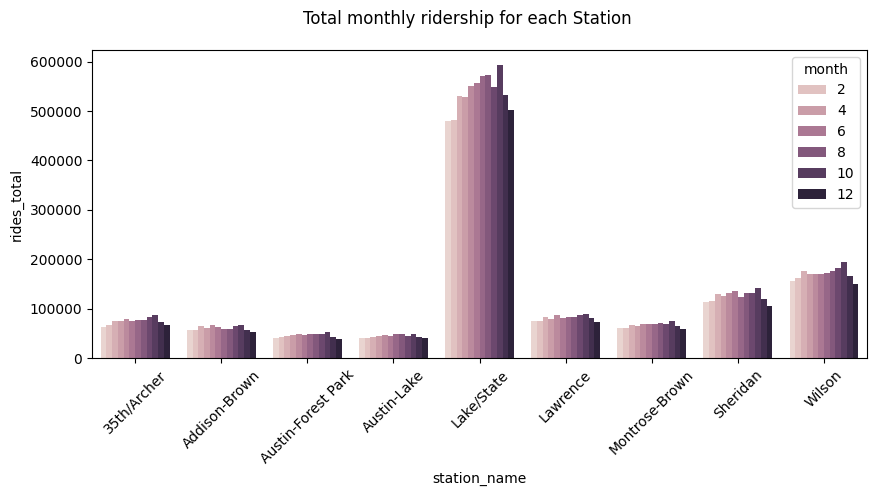

In [181]:
plt.figure(figsize=(10,4))
g = sns.barplot(data=cta_gb1, x="station_name", y="rides_total", hue="month")

g.set_xticklabels(g.get_xticklabels(),rotation=45)

g.figure.suptitle("Total monthly ridership for each Station")
plt.show()

> Lakes/State station has most ridership - mostly because its a transfer station for several subway lines. 

### Identify trends for the Wilson subway station

In [134]:
# for wilson station
cta_wilson_jul = rdshp_cal_stn[(rdshp_cal_stn["station_name"]=="Wilson") & (rdshp_cal_stn["month"]==7)]
cta_wilson_jul.head()

,station_id,year,month,day,rides,day_type,station_name,location
1641,40540,2019,7,1,6464,Weekday,Wilson,"(41.964273, -87.657588)"
1642,40540,2019,7,2,6491,Weekday,Wilson,"(41.964273, -87.657588)"
1643,40540,2019,7,3,6639,Weekday,Wilson,"(41.964273, -87.657588)"
1644,40540,2019,7,4,3515,Sunday/Holiday,Wilson,"(41.964273, -87.657588)"
1645,40540,2019,7,5,4794,Weekday,Wilson,"(41.964273, -87.657588)"


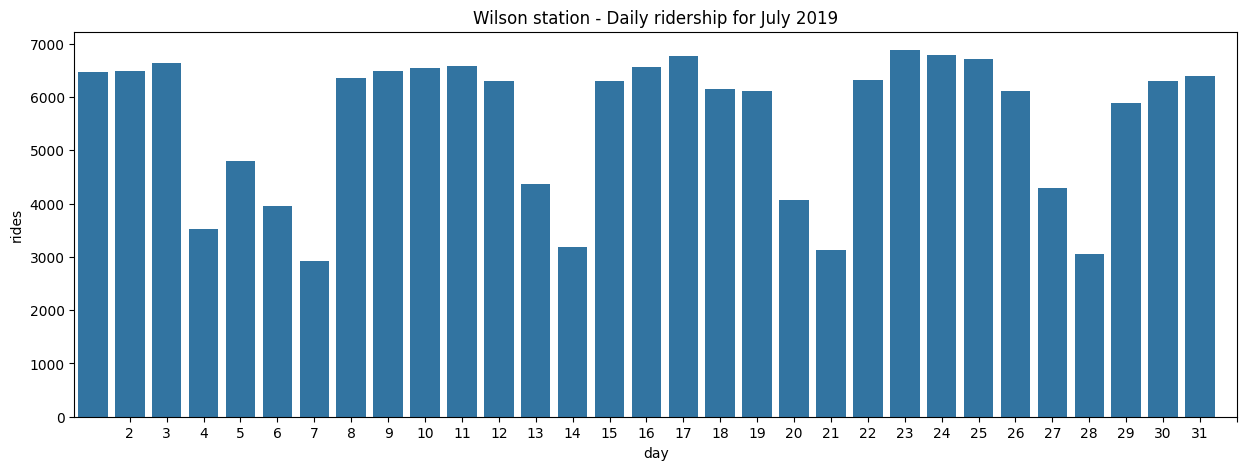

In [177]:
plt.figure(figsize=(15,5))
sns.barplot(data=cta_wilson_jul , x="day", y="rides")
plt.xticks(sorted(cta_wilson_jul["day"].unique()))
plt.title("Wilson station - Daily ridership for July 2019")
plt.show()

In [124]:
cta_pvt1 = pd.pivot_table(data=rdshp_cal_stn, index="month", columns="station_name", values="rides", aggfunc=["sum"]).round(2)
cta_pvt1

sum                                               \
station_name 35th/Archer Addison-Brown Austin-Forest Park Austin-Lake   
month                                                                   
1                  63280         55483              40799       40353   
2                  65831         56726              42096       39555   
3                  74550         64935              44146       43153   
4                  74935         60851              46858       43474   
5                  79585         67114              48136       45997   
6                  74129         61666              45723       44998   
7                  76951         57466              47627       47633   
8                  77527         59339              47617       48337   
9                  82115         64042              47986       45207   
10                 86984         66094              51902       48289   
11                 73498         57200              42042       41386   
12                 66907         53353              38601       39782   

                                                                  
station_name Lake/State Lawrence Montrose-Brown Sheridan  Wilson  
month                                                             
1                480049    74932          60177   113423  155619  
2                481530    75169          60587   115003  161834  
3                530400    82722          66295   130379  175740  
4                528643    79644          65268   124814  169374  
5                551602    87041          69149   130874  170536  
6                557473    81655          67631   135411  170459  
7                570382    82039          68393   124307  172485  
8                572898    83456          70148   130909  175620  
9                548715    87009          67951   132216  182279  
10               594404    87860          74451   142046  194515  
11               532140    81357          64549   119028  165389  
12               502603    72512          58967   105454  149537

In [125]:
cta_pvt1.columns

MultiIndex([('sum',        '35th/Archer'),
            ('sum',      'Addison-Brown'),
            ('sum', 'Austin-Forest Park'),
            ('sum',        'Austin-Lake'),
            ('sum',         'Lake/State'),
            ('sum',           'Lawrence'),
            ('sum',     'Montrose-Brown'),
            ('sum',           'Sheridan'),
            ('sum',             'Wilson')],
           names=[None, 'station_name'])

In [130]:
print(cta_pvt1.loc[7,('sum','Wilson')])

172485
